<a href="https://colab.research.google.com/github/willismax/MediaSystem-Python-Course/blob/main/12.audio-dsp/%E8%81%BD%E8%A6%8B_Sampling_%E8%88%87_Quantization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

3.8 動手驗證：聽見 Sampling 與 Quantization
===================================

Sampling 與 Quantization 如果只有公式會很抽象，本教材採「破壞性實驗」概念：**故意把參數降到不合理的程度，直接聽見系統壞掉。**

先使用 NumPy 建立 440 Hz 正弦波：

實驗一｜聽見 Aliasing
---------------


In [1]:
import numpy as np
import wave

def make_tone(freq=440, seconds=2.0, sample_rate=44100):
    t = np.linspace(
        0,
        seconds,
        int(sample_rate * seconds),
        endpoint=False
    )

    signal = np.sin(2 * np.pi * freq * t)

    # 使用 16-bit PCM 表示
    quantized = (signal * 32767).astype(np.int16)

    filename = f"tone_{freq}Hz_{sample_rate}sr.wav"

    with wave.open(filename, "w") as w:
        w.setnchannels(1)
        w.setsampwidth(2)
        w.setframerate(sample_rate)
        w.writeframes(quantized.tobytes())

    return filename


print(make_tone())
print(make_tone(sample_rate=44100))
print(make_tone(sample_rate=8000))
print(make_tone(sample_rate=1000))
print(make_tone(sample_rate=500))

tone_440Hz_44100sr.wav
tone_440Hz_44100sr.wav
tone_440Hz_8000sr.wav
tone_440Hz_1000sr.wav
tone_440Hz_500sr.wav



440 Hz 的聲音，如果依照 Nyquist 原則，Sample Rate 至少需要高於：

```text
880 Hz
```

依序產生：

```python
make_tone(sample_rate=44100)
make_tone(sample_rate=8000)
make_tone(sample_rate=1000)
make_tone(sample_rate=500)
```

前面幾個取樣率仍高於 880 Hz，而 `500 Hz` 已經低於需求。這時候取樣得到的資料無法正確描述原本的 440 Hz 正弦波，可能呈現成完全不同的低頻訊號。

觀察重點不是「音質比較差」這麼簡單，而是：

> **系統記錄到的是另一個錯誤的訊號。**

這就是 Aliasing 最重要的地方。

In [3]:
from IPython.display import Audio

file_names = [
    'tone_440Hz_44100sr.wav',
    'tone_440Hz_8000sr.wav',
    'tone_440Hz_1000sr.wav',
    'tone_440Hz_500sr.wav'
]

for filename in file_names:
    print(f"Playing {filename}:")
    display(Audio(filename))


Playing tone_440Hz_44100sr.wav:


Playing tone_440Hz_8000sr.wav:


Playing tone_440Hz_1000sr.wav:


Playing tone_440Hz_500sr.wav:


實驗二｜聽見 Quantization Error
-------------------------



這次保留 16-bit WAV 格式，但是故意降低有效量化精度，例如只保留 8、4、2 bits 的資訊，再放回 16-bit 容器播放。

可以使用位元位移模擬：

```python
def reduce_bit_depth(signal16, effective_bits):
    shift = 16 - effective_bits
    return (signal16 >> shift) << shift
```

依序比較：

```text
16 bit
8 bit
4 bit
2 bit
```

當有效 Bit Depth 大幅下降時，波形能使用的數值層級越來越少，量化誤差會逐漸變得可以聽見。

這個實驗的重點是：

```text
Sampling 沒有改
↓
時間點數量相同

Quantization 改變
↓
每個 Sample 的精度下降
```

因此可以很清楚地區分兩者。


In [4]:
import numpy as np
import wave
from IPython.display import Audio

def reduce_bit_depth(signal16, effective_bits):
    if effective_bits >= 16:
        return signal16
    shift = 16 - effective_bits
    return (signal16 >> shift) << shift

freq = 440
seconds = 2.0
sample_rate = 44100 # Keep a high sample rate to focus on quantization

# Recreate the original 16-bit signal data (from the make_tone function logic)
# This avoids dependencies on previously saved files for the base signal.
t = np.linspace(0, seconds, int(sample_rate * seconds), endpoint=False)
signal_float = np.sin(2 * np.pi * freq * t)
original_signal_16bit = (signal_float * 32767).astype(np.int16)

def save_wav_with_bit_depth(signal_array, sample_rate, effective_bits):
    filename = f"tone_{freq}Hz_sr{sample_rate}_bit{effective_bits}.wav"
    with wave.open(filename, "w") as w:
        w.setnchannels(1)
        w.setsampwidth(2)  # Always save as 16-bit WAV container
        w.setframerate(sample_rate)
        w.writeframes(signal_array.tobytes())
    return filename

print("實驗二｜聽見 Quantization Error")
print("---------------------------------------")

# List to hold filenames for playing
audio_files_to_play = []

# Generate and save audio for different effective bit depths
for bits in [16, 8, 4, 2]:
    print(f"正在生成 {bits}-bit 有效位元深度音訊...")
    if bits == 16:
        # For 16 bits, use the original 16-bit signal directly
        processed_signal = original_signal_16bit
    else:
        # Apply bit depth reduction for less than 16 bits
        processed_signal = reduce_bit_depth(original_signal_16bit, bits)

    filename = save_wav_with_bit_depth(processed_signal, sample_rate, bits)
    audio_files_to_play.append(filename)

print("\n播放生成的音訊檔案：")
for filename in audio_files_to_play:
    print(f"播放 {filename}:")
    display(Audio(filename))


實驗二｜聽見 Quantization Error
---------------------------------------
正在生成 16-bit 有效位元深度音訊...
正在生成 8-bit 有效位元深度音訊...
正在生成 4-bit 有效位元深度音訊...
正在生成 2-bit 有效位元深度音訊...

播放生成的音訊檔案：
播放 tone_440Hz_sr44100_bit16.wav:


播放 tone_440Hz_sr44100_bit8.wav:


播放 tone_440Hz_sr44100_bit4.wav:


播放 tone_440Hz_sr44100_bit2.wav:


# 實驗小結



單純聽「逼～」的聲音時，兩者的差異在於「音調（頻率）有沒有跑掉」**與**「音質純不純（雜音多寡）」。

**實驗一｜聽見 Aliasing（混疊）**

* **聽覺特徵**：在 Sample Rate 足夠（如 44.1 kHz、8000 Hz、1000 Hz）時，聽到的都是標準的 440 Hz 音高（標準音 A）。當取樣率降到 500 Hz 時，由於低於 Nyquist 頻率門檻（440 × 2 = 880 Hz），系統產生的不再是 440 Hz，而是混疊後的 **60 Hz 低頻「逼～」**（$\vert{}500 - 440\vert{} = 60$ Hz）。
* **教學解釋**：取樣率不足時，電腦不是單純讓「音質變差」，而是直接**把訊號誤認成完全不同的頻率**。

**實驗二｜聽見 Quantization Error（量化誤差）**

* **聽覺特徵**：音高（440 Hz）始終沒有改變，但在 16-bit 下是平滑乾淨的純單音；降到 8-bit、4-bit、2-bit 時，原本圓滑的正弦波被切成階梯狀（接近方波/鋸齒波），「逼～」聲中會混入越來越明顯的**沙沙雜音、毛邊與金屬毛刺感**（8-bit 復古遊戲音效感）。
* **教學解釋**：取樣點時間完全沒變，但每次能記錄的數值精度大幅降低，數值誤差轉化為**量化雜訊與諧波失真**。

| 實驗維度 | 實驗一：Aliasing | 實驗二：Quantization Error |
| --- | --- | --- |
| **改變的參數** | 取樣率（Sample Rate） | 位元深度（Bit Depth） |
| **音高（頻率）** | **改變**（直接變成別的音） | **不變**（依然是 440 Hz） |
| **音質（波形）** | 乾淨，但頻率錯誤 | 出現明顯雜音、毛邊與失真 |
| **結論** | 「有沒有量到原本的節奏」 | 「量到的數值記得到底準不準」 |

## 3.9 視覺化教學輔助：用眼睛「看見」取樣與量化

除了直接用耳朵聽之外，透過波形圖的視覺化，我們能更直觀地向學生展示 Aliasing（混疊）與 Quantization Error（量化誤差）在數學與物理上的真實樣貌。

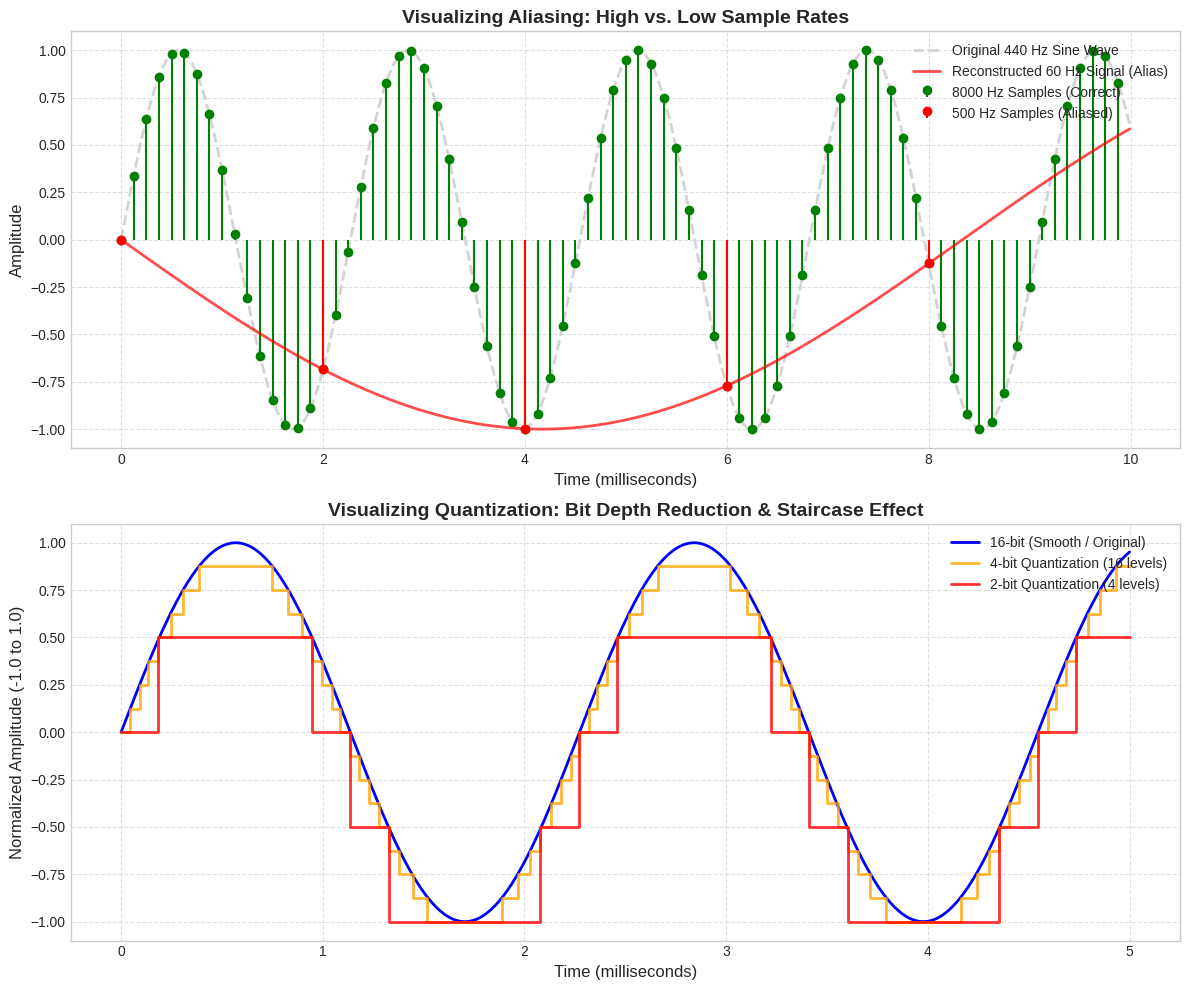

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 設定中文字型與樣式（若系統不支援中文，可使用預設樣式並以英文輔助）
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# --- 1. Aliasing 視覺化 ---
# 為了看清楚波形細節，我們只繪製前 10 毫秒 (0.01 秒) 的訊號
t_plot_max = 0.01
t_dense = np.linspace(0, t_plot_max, 1000, endpoint=False)
signal_dense = np.sin(2 * np.pi * 440 * t_dense)

# 8000 Hz 取樣點
sr_high = 8000
t_high = np.arange(0, t_plot_max, 1/sr_high)
signal_high = np.sin(2 * np.pi * 440 * t_high)

# 500 Hz 取樣點 (低於 Nyquist 880 Hz)
sr_low = 500
t_low = np.arange(0, t_plot_max, 1/sr_low)
signal_low = np.sin(2 * np.pi * 440 * t_low)

# 預期混疊後的 60 Hz 訊號 (用於對照說明)
signal_alias_60hz = np.sin(2 * np.pi * 60 * t_dense)

ax1 = axes[0]
ax1.plot(t_dense * 1000, signal_dense, label='Original 440 Hz Sine Wave', color='lightgray', linestyle='--', linewidth=2)
ax1.stem(t_high * 1000, signal_high, linefmt='g-', markerfmt='go', label='8000 Hz Samples (Correct)', basefmt=' ')
ax1.stem(t_low * 1000, signal_low, linefmt='r-', markerfmt='ro', label='500 Hz Samples (Aliased)', basefmt=' ')
# 繪製通過 500 Hz 取樣點的錯誤重建波形 (60 Hz)
ax1.plot(t_dense * 1000, -signal_alias_60hz, label='Reconstructed 60 Hz Signal (Alias)', color='red', alpha=0.7, linewidth=2)

ax1.set_title('Visualizing Aliasing: High vs. Low Sample Rates', fontsize=14, fontweight='bold')
ax1.set_xlabel('Time (milliseconds)', fontsize=12)
ax1.set_ylabel('Amplitude', fontsize=12)
ax1.legend(loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.6)

# --- 2. Quantization Error 視覺化 ---
# 我們同樣觀察一小段正弦波，看看不同 Bit Depth 對波形連續性的破壞
t_q = np.linspace(0, 0.005, 500) # 5 毫秒
signal_q_float = np.sin(2 * np.pi * 440 * t_q)
signal_q_16bit = (signal_q_float * 32767).astype(np.int16)

def reduce_bits_for_plot(sig16, bits):
    shift = 16 - bits
    return ((sig16 >> shift) << shift) / 32767.0

sig_16 = signal_q_16bit / 32767.0
sig_4 = reduce_bits_for_plot(signal_q_16bit, 4)
sig_2 = reduce_bits_for_plot(signal_q_16bit, 2)

ax2 = axes[1]
ax2.plot(t_q * 1000, sig_16, label='16-bit (Smooth / Original)', color='blue', linewidth=2)
ax2.step(t_q * 1000, sig_4, label='4-bit Quantization (16 levels)', color='orange', where='mid', alpha=0.8, linewidth=2)
ax2.step(t_q * 1000, sig_2, label='2-bit Quantization (4 levels)', color='red', where='mid', alpha=0.8, linewidth=2)

ax2.set_title('Visualizing Quantization: Bit Depth Reduction & Staircase Effect', fontsize=14, fontweight='bold')
ax2.set_xlabel('Time (milliseconds)', fontsize=12)
ax2.set_ylabel('Normalized Amplitude (-1.0 to 1.0)', fontsize=12)
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### 💡 課堂引導與說明重點

1. **圖一（Aliasing 混疊）**：
   - 請學生看**綠色點（8000 Hz）**：取樣點非常密集，完美貼合在原本的灰色虛線（440 Hz）上。
   - 再看**紅色點（500 Hz）**：因為取樣頻率太低，在這 10 毫秒內只點到了 5 個點。這 5 個紅色點連起來後，會勾勒出一條非常緩慢、頻率極低的**紅色實線（60 Hz 訊號）**。這就是為什麼聲音會從高音「逼」變成低音「嘟」，因為電腦把這幾個點誤認成 60 Hz 了！

2. **圖二（Quantization 量化）**：
   - 請學生看**藍色線（16-bit）**：波形極度平滑，幾乎與完美的正弦波無異。
   - 看**橘色線（4-bit）**與**紅色線（2-bit）**：原本平滑的波形變成了鋸齒狀的**「階梯」**。階梯的直角轉折在訊號處理中代表著「瞬間的高頻變化」，這在聽覺上就會轉化為我們聽到的**沙沙雜音（量化雜訊）與金屬毛刺感**。

## 3.10 互動教具：使用 Gradio 打造動態取樣與量化模擬器

為了讓課堂演示更生動，我們可以使用 Gradio 套件建立一個即時互動介面。您可以手動拖動取樣率與位元深度的拉桿，網頁會即時繪製對應的波形，讓學生秒懂這兩個參數如何共同影響波形！

*請先安裝 `gradio` 套件（若尚未安裝），然後執行下方的程式碼。*

In [6]:
!pip install -q gradio

In [13]:
import gradio as gr
import pandas as pd
import numpy as np

def simulate_dsp_native(sample_rate, bit_depth):
    freq = 440
    t_max = 0.01  # 觀察 10 毫秒

    # 1. 建立背景高密度「原始波形」資料
    t_dense = np.linspace(0, t_max, 300, endpoint=False)
    sig_dense = np.sin(2 * np.pi * freq * t_dense)

    # 2. 模擬取樣與量化
    t_sampled = np.arange(0, t_max, 1 / sample_rate)
    if len(t_sampled) == 0:
        t_sampled = np.array([0.0])

    sig_sampled = np.sin(2 * np.pi * freq * t_sampled)

    # 量化計算
    levels = 2 ** bit_depth
    sig_normalized = (sig_sampled + 1.0) / 2.0
    sig_quantized_idx = np.round(sig_normalized * (levels - 1))
    sig_quantized = (sig_quantized_idx / (levels - 1)) * 2.0 - 1.0

    # 3. 為了在網頁上做出漂亮的階梯狀(Step)效果，我們建立階梯連續資料
    t_step = []
    sig_step = []
    for i in range(len(t_sampled)):
        t_start = t_sampled[i]
        t_end = t_sampled[i] + (1 / sample_rate) if i < len(t_sampled) - 1 else t_max

        t_step.extend([t_start, t_end])
        sig_step.extend([sig_quantized[i], sig_quantized[i]])

    # 限制階梯資料不超出畫幅
    t_step = np.minimum(t_step, t_max)

    # 4. 組合成 Pandas DataFrame 以利 Gradio Native LinePlot 繪製
    df_dense = pd.DataFrame({
        "Time (ms)": t_dense * 1000,
        "Amplitude": sig_dense,
        "Signal Type": "Original (440 Hz)"
    })

    df_step = pd.DataFrame({
        "Time (ms)": np.array(t_step) * 1000,
        "Amplitude": sig_step,
        "Signal Type": f"Sampled & Quantized ({bit_depth}-bit)"
    })

    # 合併兩個資料集
    df_plot = pd.concat([df_dense, df_step], ignore_index=True)

    # 判斷 Nyquist 狀態文字
    nyquist_status = "符合 (無混疊)" if sample_rate >= 880 else "不符合 (發生混疊 Aliasing!)"
    status_html = f"""
    <div style='background-color: {'#e8f5e9' if sample_rate >= 880 else '#ffebee'};
                padding: 15px; border-radius: 8px; border-left: 5px solid {'#4caf50' if sample_rate >= 880 else '#f44336'};'>
        <h4 style='margin: 0; color: {'#2e7d32' if sample_rate >= 880 else '#c62828'}; font-weight: bold;'>
            奈奎斯特準則驗證：{nyquist_status}
        </h4>
        <p style='margin: 5px 0 0 0; color: #555; font-size: 14px;'>
            訊號頻率：440 Hz │ 必要最低取樣率：880 Hz │ 目前設定：{sample_rate} Hz<br>
            量化階數：{levels} 等級 (2<sup>{bit_depth}</sup>)
        </p>
    </div>
    """

    return df_plot, status_html

# 建立 Gradio 區塊介面
with gr.Blocks(title="聲音物理即時模擬器") as demo:
    gr.Markdown("# 🎙️ 聲音物理課堂：取樣與量化即時模擬器")
    gr.Markdown("拖動下方拉桿，即可即時以互動向量圖觀察訊號在不同取樣率與位元深度下的離散化與失真樣貌。")

    with gr.Row():
        with gr.Column(scale=1):
            sr_slider = gr.Slider(minimum=200, maximum=8000, step=100, value=8000, label="取樣頻率 Sample Rate (Hz)")
            bit_slider = gr.Slider(minimum=1, maximum=16, step=1, value=16, label="位元深度 Bit Depth (Bits)")
            status_output = gr.HTML()

        with gr.Column(scale=2):
            plot_output = gr.LinePlot(
                x="Time (ms)",
                y="Amplitude",
                color="Signal Type",
                title="模擬波形即時顯示器",
                tooltip=["Time (ms)", "Amplitude", "Signal Type"],
                y_lim=[-1.2, 1.2]
            )

    # 連接動態更新動作
    inputs = [sr_slider, bit_slider]
    outputs = [plot_output, status_output]

    sr_slider.change(fn=simulate_dsp_native, inputs=inputs, outputs=outputs)
    bit_slider.change(fn=simulate_dsp_native, inputs=inputs, outputs=outputs)
    # 初始化載入
    demo.load(fn=simulate_dsp_native, inputs=inputs, outputs=outputs)

# 啟動介面，開啟 share=True 產生公開外部連結
default_share = True
demo.launch(inline=True, share=default_share)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9cb27045769ac493b8.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
